In [ ]:
import os
os.chdir('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code')

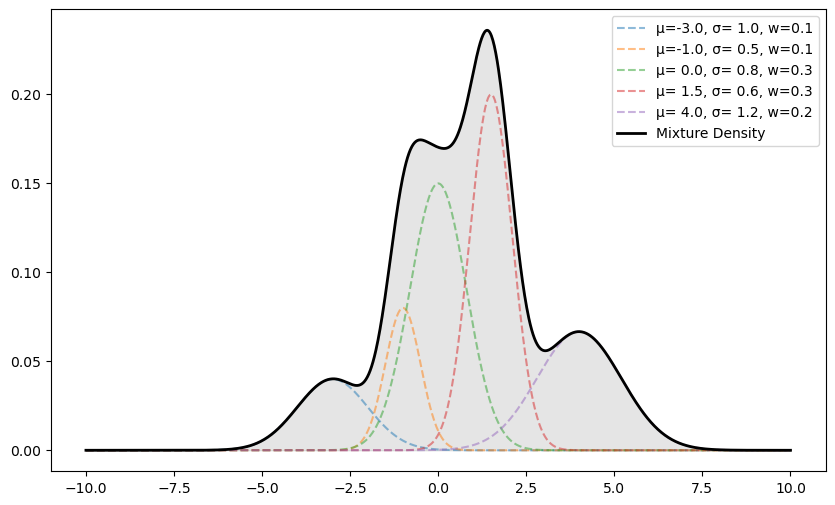

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置5个正态分布的参数 (均值, 标准差, 权重)
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]

x = np.linspace(-10, 10, 1000)
mixture = np.zeros_like(x)

plt.figure(figsize=(10, 6))

for m, s, w in params:
    component = w * norm.pdf(x, m, s)
    mixture += component
    plt.plot(x, component, '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w}') # 画出单个成分

# plot the 5% var or 

plt.plot(x, mixture, color='black', lw=2, label='Mixture Density') # 画出混合后的总曲线
plt.fill_between(x, mixture, color='gray', alpha=0.2)
plt.legend()
# save the figure as pdf
plt.savefig('../paper/fig/mixture_density_example.pdf',  bbox_inches='tight')
plt.show()


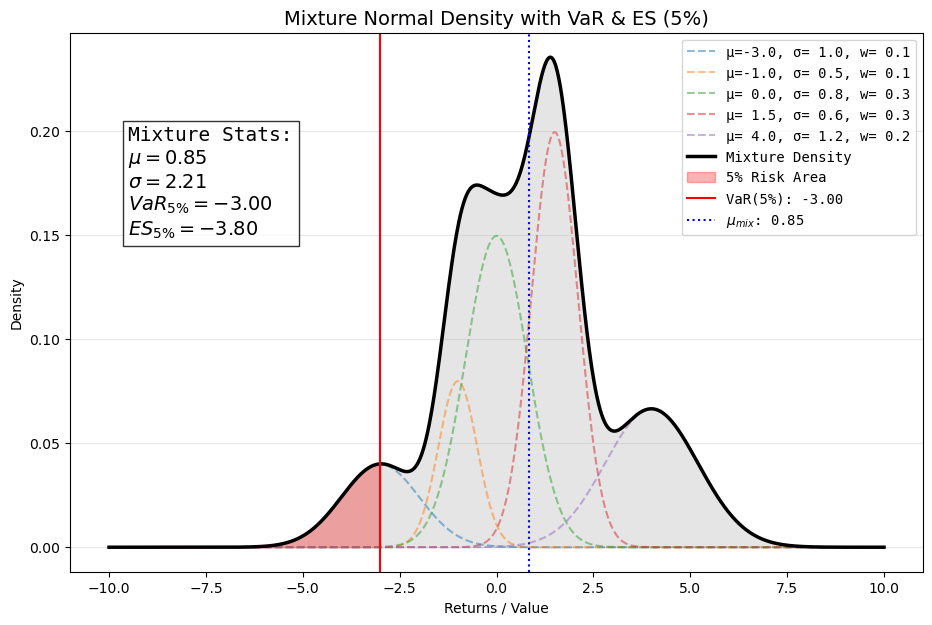

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import fsolve

# 1. 基础参数
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]
x = np.linspace(-10, 10, 1000)

# 2. 定义混合分布的 PDF 和 CDF
def mixture_pdf(x_val):
    return sum(w * norm.pdf(x_val, m, s) for m, s, w in params)

def mixture_cdf(x_val):
    return sum(w * norm.cdf(x_val, m, s) for m, s, w in params)

# 计算混合分布的整体均值 (mu) 和 标准差 (sigma)
mix_mu = sum(w * m for m, s, w in params)
# 混合分布方差公式: E[X^2] - (E[X])^2
mix_var = sum(w * (s**2 + m**2) for m, s, w in params) - mix_mu**2
mix_sigma = np.sqrt(mix_var)

# 3. 数值计算 5% VaR
# VaR 是满足 CDF(x) = 0.05 的那个 x
var_5pct = fsolve(lambda x: mixture_cdf(x) - 0.05, -5)[0]

# 4. 数值计算 5% Expected Shortfall (ES)
# ES = (1/alpha) * integral from -inf to VaR of (x * pdf)
es_res, _ = quad(lambda x: x * mixture_pdf(x), -20, var_5pct)
es_5pct = es_res / 0.05

# --- 开始绘图 ---
plt.figure(figsize=(11, 7))
y_mixture = [mixture_pdf(val) for val in x]

# 画出单个成分
for m, s, w in params:
    # plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.3, lw=1)
    plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w:>4.1f}') # 画出单个成分

# 画出混合曲线
plt.plot(x, y_mixture, color='black', lw=2.5, label='Mixture Density')

# 5. 标注 VaR 区域 (左侧 5% 尾部)
x_tail = np.linspace(-10, var_5pct, 200)
plt.fill_between(x, mixture, color='gray', alpha=0.2)
plt.fill_between(x_tail, [mixture_pdf(v) for v in x_tail], color='red', alpha=0.3, label='5% Risk Area')

# 6. 画出 VaR, ES 和 Mu 的垂直线
plt.axvline(var_5pct, color='red', linestyle='-', lw=1.5, label=f'VaR(5%): {var_5pct:.2f}') 
# plt.axvline(es_5pct, color='darkred', linestyle='-.', lw=1.5, label=f'ES(5%): {es_5pct:.2f}')
plt.axvline(mix_mu, color='blue', linestyle=':', lw=1.5, label=f'$\mu_{{mix}}$: {mix_mu:.2f}')

# 文本框标注统计量
stats_text = (f'Mixture Stats:\n'
              f'$\mu = {mix_mu:.2f}$\n'
              f'$\sigma = {mix_sigma:.2f}$\n'
              f'$VaR_{{5\%}} = {var_5pct:.2f}$\n'
              f'$ES_{{5\%}} = {es_5pct:.2f}$')
plt.text(-9.5, 0.15, stats_text, bbox=dict(facecolor='white', alpha=0.8), fontsize=14, family='monospace')

# 格式化
plt.title('Mixture Normal Density with VaR & ES (5%)', fontsize=14)
plt.xlabel('Returns / Value')
plt.ylabel('Density')
plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
plt.grid(axis='y', alpha=0.3)

# 保存
plt.savefig('../paper/fig/mixture_density_example.pdf',  bbox_inches='tight')
plt.show()

In [ ]:
# 每个步骤一张图, 用于动画切片 (Slices)
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import fsolve

# 确保文件夹存在
if not os.path.exists('fig'):
    os.makedirs('fig')

# 1. 基础参数与计算 (保持你的逻辑不变)
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]
x = np.linspace(-10, 10, 1000)

def mixture_pdf(x_val):
    return sum(w * norm.pdf(x_val, m, s) for m, s, w in params)

def mixture_cdf(x_val):
    return sum(w * norm.cdf(x_val, m, s) for m, s, w in params)

mix_mu = sum(w * m for m, s, w in params)
mix_var = sum(w * (s**2 + m**2) for m, s, w in params) - mix_mu**2
mix_sigma = np.sqrt(mix_var)

var_5pct = fsolve(lambda x: mixture_cdf(x) - 0.05, -5)[0]
es_res, _ = quad(lambda x: x * mixture_pdf(x), -20, var_5pct)
es_5pct = es_res / 0.05
y_mixture = [mixture_pdf(val) for val in x]

# ==========================================
# 开始生成动画切片 (Slices)
# ==========================================

plt.figure(figsize=(11, 7))

# 统一的图表格式设置
plt.title('Mixture Normal Density with VaR & ES (5%)', fontsize=14)
plt.xlabel('Returns / Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
# 固定 y 轴范围，防止后续加线时画面跳动 (重要！)
plt.ylim(0, max(y_mixture) * 1.2) 

# --- 阶段 1：逐个出现 Normal 线 ---
for i, (m, s, w) in enumerate(params):
    plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w:>4.1f}')
    plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
    # 保存第 1 到 5 帧
    plt.savefig(f'../paper/fig/slice_1_comp_{i+1}.pdf', bbox_inches='tight')

# --- 阶段 2：出现 Mixture 黑色粗线 ---
plt.plot(x, y_mixture, color='black', lw=2.5, label='Mixture Density')
plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
# 修复了你原本代码里 mixture 变量未定义的 bug
plt.fill_between(x, y_mixture, color='gray', alpha=0.1) 
# 保存第 6 帧
plt.savefig('../paper/fig/slice_2_mixture.pdf', bbox_inches='tight')

# --- 阶段 3：出现 VaR 红色区域和统计数据 ---
x_tail = np.linspace(-10, var_5pct, 200)
plt.fill_between(x_tail, [mixture_pdf(v) for v in x_tail], color='red', alpha=0.3, label='5% Risk Area')
plt.axvline(var_5pct, color='red', linestyle='-', lw=1.5, label=f'VaR(5%): {var_5pct:.2f}') 
plt.axvline(mix_mu, color='blue', linestyle=':', lw=1.5, label=f'$\mu_{{mix}}$: {mix_mu:.2f}')

stats_text = (f'Mixture Stats:\n'
              f'$\mu = {mix_mu:.2f}$\n'
              f'$\sigma = {mix_sigma:.2f}$\n'
              f'$VaR_{{5\%}} = {var_5pct:.2f}$\n'
              f'$ES_{{5\%}} = {es_5pct:.2f}$')
plt.text(-9.5, 0.15, stats_text, bbox=dict(facecolor='white', alpha=0.8), fontsize=14, family='monospace')

plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
# 保存第 7 帧 (终极版)
plt.savefig('../paper/fig/slice_3_final_var.pdf', bbox_inches='tight')

plt.close() # 绘图完毕，关闭内存中的画布
print("动画切片生成完毕！请查看 fig 文件夹。")

动画切片生成完毕！请查看 fig 文件夹。
